## Profiling of Single Conversion Code in Knowledge Graph 
This section discusses the code snippet used to perform a single conversion within the knowledge graph profiling process.

In [1]:
!git clone https://github.com/c3di/im2im.git

import os
os.chdir('im2im')

Cloning into 'im2im'...
remote: Enumerating objects: 2719, done.
remote: Counting objects: 100% (717/717), done.
remote: Compressing objects: 100% (231/231), done.
remote: Total 2719 (delta 479), reused 672 (delta 448), pack-reused 2002 (from 1)
Receiving objects: 100% (2719/2719), 1.82 MiB | 2.22 MiB/s, done.
Resolving deltas: 100% (1669/1669), done.


In [2]:
%pip install py-cpuinfo
%pip install gputil

import cpuinfo
import GPUtil

cpu_name = cpuinfo.get_cpu_info()['brand_raw']
print(f"CPU: {cpu_name}")

gpus = GPUtil.getGPUs()
print(f"GPU:0: {GPUtil.getGPUs()[0].name}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
CPU: Intel(R) Core(TM) i7-7700K CPU @ 4.20GHz
GPU:0: NVIDIA GeForce GTX 1080 Ti


In [3]:
import matplotlib.pyplot as plt
import numpy as np


def histogram(data, title, bins=5):
    bin_edges = np.linspace(0, max(data), bins + 1)
    n, bins, patches = plt.hist(data, bins=bin_edges, alpha=0.7)
    for patch in patches:
        height = patch.get_height()
        plt.annotate(f'{int(height)}',
                     (patch.get_x() + patch.get_width() / 2, height),
                     textcoords="offset points",
                     xytext=(0,5),
                     ha='center')
    plt.title(title)
    plt.xlabel('Execution Time (s)')
    plt.xticks(bin_edges)
    plt.ylabel('Number')
    plt.show()

2024-08-15 14:15:20.476786: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-15 14:15:21.217457: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-08-15 14:15:25.703978: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-08-15 14:15:25.704170: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required li

Execution time: 1.7499999671599653e-07 to 0.0019612616000017624 for image size (128, 128).


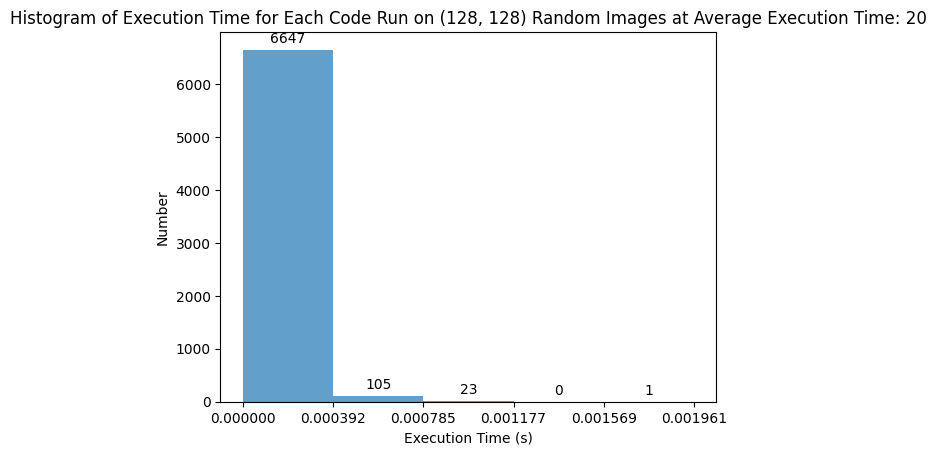

Execution time: 1.849999989644857e-07 to 0.0025212398999997277 for image size (256, 256).


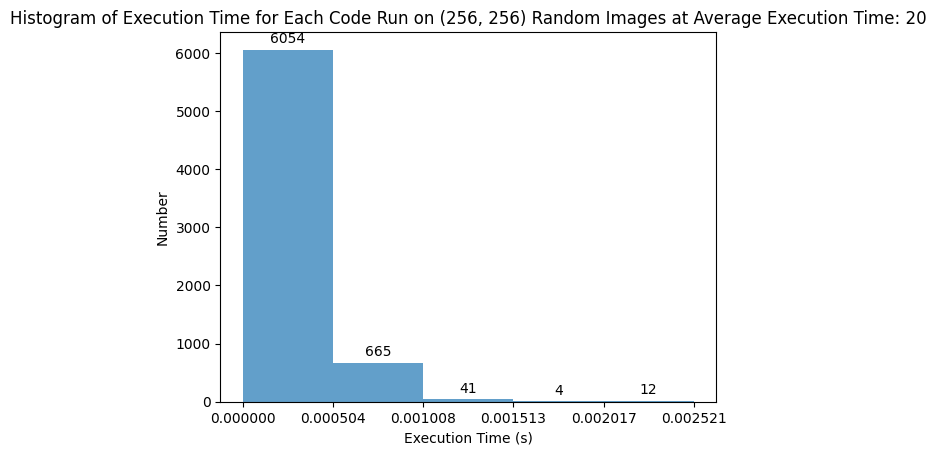

Execution time: 1.8000000068241206e-07 to 0.01074226834999763 for image size (512, 512).


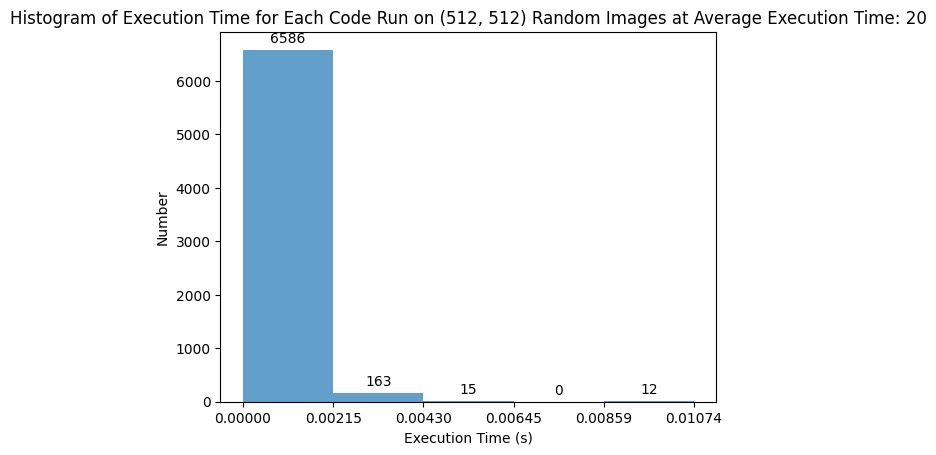

Execution time: 1.850000046488276e-07 to 0.04009475674999976 for image size (1024, 1024).


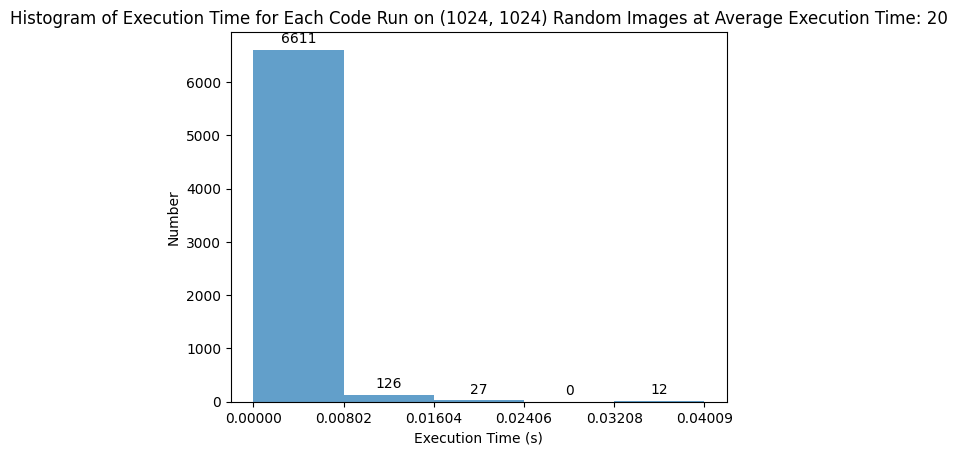

Execution time: 2.049999920927803e-07 to 0.16375802124999836 for image size (2048, 2048).


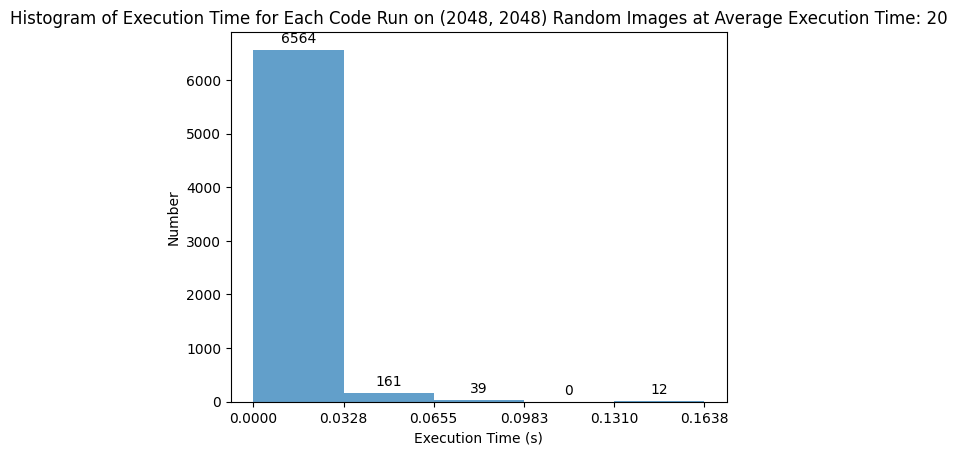

In [4]:
from src.im2im import _constructor
from tests.time_cost_measure import time_cost_in_kg

kg = _constructor.knowledge_graph

repeat_count = 20
for img_size in [(128, 128), (256, 256), (512, 512), (1024, 1024), (2048, 2048)]:
    time_costs = time_cost_in_kg(kg, img_size, repeat_count)
    
    print(f"Execution time: {min(time_costs.values())} to {max(time_costs.values())} for image size {img_size}.")
    histogram(time_costs.values(), f"Histogram of Execution Time for Each Code Run on {img_size} Random Images at Average Execution Time: {repeat_count}")